# Symbolic Analysis for "Emulator Superiority"

The notebook below has all the symbolic manipulations using `SymPy` done for the
paper "Neural Emulator Superiority: When Machine Learning for PDEs Surpasses its
Training Data". It produces all the plots in the paper, writes out the
expressions as latex code (which have been partially embedded into the paper),
and as an HTML table.

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.autonotebook import tqdm

/tmp/ipykernel_879823/1147484584.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
phi = sp.symbols(
    "phi",
    real=True,
    positive=True,
    domain=sp.Interval(0, 1 / 2),
)
psi = sp.symbols(
    "psi",
    real=True,
    positive=True,
    domain=sp.Interval(0, 1 / 2),
)
gamma_1 = sp.symbols(
    "gamma_1",
    real=True,
    negative=True,
)
gamma_2 = sp.symbols(
    "gamma_2",
    real=True,
    positive=True,
)
q = sp.symbols(
    "q",
    real=True,
    positive=True,
    integer=True,
)
dx = sp.symbols(
    "Delta",
    real=True,
    positive=True,
) # Needed for Poisson, but cancels for most expressions
T = sp.symbols("T", real=True, positive=True, integer=True)

In [3]:
theta_0, theta_1 = sp.symbols("theta_0, theta_1", real=True)

In [4]:
theta = sp.symbols("theta", real=True)

In [5]:
PARAMETER_RANGES = {
    "gamma_1": np.array([-0.03, -0.3, -3.0]),
    "gamma_2": np.array([0.03, 0.3, 3.0]),
    "iteration": np.array([1, 3, 10, 30, 100, 300, 1000]),
    None: np.array([1.0]),
}
PSI_RANGE = np.array([0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3])
PHI_RANGE = 10 ** np.linspace(np.log10(0.003), np.log10(0.5), 100)
T_RANGE = np.concatenate([np.arange(1, 200 + 1), np.arange(201, 100000 + 1, 200)])

# Advection
The below cell runs for ~2min due to the `.simplify()` calls on the superiority ratios.

In [6]:
# All schemes and the ansatz scheme
adv_e = 1 + gamma_1 * (1 - sp.exp(-sp.I * 2 * sp.pi * phi))
adv_i = 1 / (1 - gamma_1 * (1 - sp.exp(-sp.I * 2 * sp.pi * phi)))
adv_a = sp.exp(sp.I * gamma_1 * 2 * sp.pi * phi)
adv_h = theta_1 + theta_0 * sp.exp(-sp.I * 2 * sp.pi * phi)

# Relative Magnitude and Phase Errors of the numerical schemes
adv_magnitude_error_e = (sp.re(sp.Abs(adv_e) - sp.Abs(adv_a)) / sp.Abs(adv_a)).simplify()
adv_magnitude_error_i = (sp.re(sp.Abs(adv_i) - sp.Abs(adv_a)) / sp.Abs(adv_a)).simplify()
adv_phase_error_e = (sp.re(sp.Abs(sp.arg(adv_e)) - sp.Abs(sp.arg(adv_a))) / sp.Abs(sp.arg(adv_a))).simplify()
adv_phase_error_i = (sp.re(sp.Abs(sp.arg(adv_i)) - sp.Abs(sp.arg(adv_a))) / sp.Abs(sp.arg(adv_a))).simplify()

# Solution for theta_0 and theta_1 when fitting at relative mode psi
adv_i_sol = sp.solve(adv_h.subs(phi, psi) - adv_i.subs(phi, psi), (theta_0, theta_1))
adv_a_sol = sp.solve(adv_h.subs(phi, psi) - adv_a.subs(phi, psi), (theta_0, theta_1))
adv_e_sol = sp.solve(adv_h.subs(phi, psi) - adv_e.subs(phi, psi), (theta_0, theta_1))

# Ansatz with plugged in solutions
adv_h_i = adv_h.subs(adv_i_sol).simplify()
adv_h_a = adv_h.subs(adv_a_sol).simplify()
adv_h_e = adv_h.subs(adv_e_sol).simplify()

# Superiority ratios both in terms of the magnitude and the phase
adv_abs_i_i_a = sp.re((sp.Abs(adv_h_i) - sp.Abs(adv_a)) / (sp.Abs(adv_i) - sp.Abs(adv_a))).simplify()
adv_abs_a_i_a = sp.re((sp.Abs(adv_h_a) - sp.Abs(adv_a)) / (sp.Abs(adv_i) - sp.Abs(adv_a))).simplify()
adv_abs_i_e_a = sp.re((sp.Abs(adv_h_i) - sp.Abs(adv_a)) / (sp.Abs(adv_e) - sp.Abs(adv_a))).simplify()
adv_abs_a_e_a = sp.re((sp.Abs(adv_h_a) - sp.Abs(adv_a)) / (sp.Abs(adv_e) - sp.Abs(adv_a))).simplify()
adv_abs_e_i_a = sp.re((sp.Abs(adv_h_e) - sp.Abs(adv_a)) / (sp.Abs(adv_i) - sp.Abs(adv_a))).simplify()
adv_abs_e_a_a = sp.re((sp.Abs(adv_h_e) - sp.Abs(adv_a)) / (sp.Abs(adv_a) - sp.Abs(adv_a))).simplify()

adv_arg_i_i_a = (sp.arg(adv_h_i) - sp.arg(adv_a)) / (sp.arg(adv_i) - sp.arg(adv_a)).simplify()
adv_arg_a_i_a = (sp.arg(adv_h_a) - sp.arg(adv_a)) / (sp.arg(adv_i) - sp.arg(adv_a)).simplify()
adv_arg_i_e_a = (sp.arg(adv_h_i) - sp.arg(adv_a)) / (sp.arg(adv_e) - sp.arg(adv_a)).simplify()
adv_arg_a_e_a = (sp.arg(adv_h_a) - sp.arg(adv_a)) / (sp.arg(adv_e) - sp.arg(adv_a)).simplify()
adv_arg_e_i_a = (sp.arg(adv_h_e) - sp.arg(adv_a)) / (sp.arg(adv_i) - sp.arg(adv_a)).simplify()
adv_arg_e_a_a = (sp.arg(adv_h_e) - sp.arg(adv_a)) / (sp.arg(adv_a) - sp.arg(adv_a)).simplify()

# Diffusion

In [7]:
# All schemes and the ansatz scheme
diff_e = 1 + gamma_2 * (sp.cos(2 * sp.pi * phi) - 1)
diff_i = 1 / (1 - gamma_2 * (sp.cos(2 * sp.pi * phi) - 1))
diff_a = sp.exp(-gamma_2 / 2 * (2 * sp.pi * phi) ** 2)
diff_h = diff_e.subs(gamma_2, theta)

# Relative Magnitude Errors of the numerical schemes
diff_magnitude_error_e = (sp.re(diff_e - diff_a) / sp.Abs(diff_a)).simplify()
diff_magnitude_error_i = (sp.re(diff_i - diff_a) / sp.Abs(diff_a)).simplify()

# Solution for theta
diff_i_sol = sp.solve(diff_h.subs(phi, psi) - diff_i.subs(phi, psi), (theta))[0].simplify()
diff_a_sol = sp.solve(diff_h.subs(phi, psi) - diff_a.subs(phi, psi), (theta))[0].simplify()
diff_e_sol = sp.solve(diff_h.subs(phi, psi) - diff_e.subs(phi, psi), (theta))[0].simplify()

# Ansatz with plugged in solutions
diff_h_i = diff_h.subs(theta, diff_i_sol).simplify()
diff_h_a = diff_h.subs(theta, diff_a_sol).simplify()
diff_h_e = diff_h.subs(theta, diff_e_sol).simplify()

# Superiority ratios in terms of magnitude
diff_abs_i_i_a = ((diff_h_i - diff_a) / (diff_i - diff_a)).simplify()
diff_abs_a_i_a = ((diff_h_a - diff_a) / (diff_i - diff_a)).simplify()
diff_abs_i_e_a = ((diff_h_i - diff_a) / (diff_e - diff_a)).simplify()
diff_abs_a_e_a = ((diff_h_a - diff_a) / (diff_e - diff_a)).simplify()
diff_abs_e_i_a = ((diff_h_e - diff_a) / (diff_i - diff_a)).simplify()

# Poisson

In [8]:
# poiss_fd2 = dx**2 / (2 * (1 - sp.cos(2 * sp.pi * phi)))
# poiss_a = dx**2 / phi**2 / (2 * sp.pi) ** 2
# poiss_iter = (
#     dx**2 / 2 * (1 - sp.cos(2 * sp.pi * phi) ** q) / (1 - sp.cos(2 * sp.pi * phi))
# )
poiss_fd2 = 1 / (2 * (1 - sp.cos(2 * sp.pi * phi))) + 0 * q # Create artificial dependency on q
poiss_a = 1 / phi**2 / (2 * sp.pi) ** 2 + 0 * q # Create artificial dependency on q
poiss_iter = (
    1 / 2 * (1 - sp.cos(2 * sp.pi * phi) ** q) / (1 - sp.cos(2 * sp.pi * phi))
)
poiss_h = theta / (2 * (1 - sp.cos(2 * sp.pi * phi)))

# Relative Magnitude Errors of the numerical schemes
poiss_magnitude_error_fd2 = (sp.re(sp.Abs(poiss_fd2) - sp.Abs(poiss_a)) / sp.Abs(poiss_a)).simplify()
poiss_magnitude_error_iterative = (sp.re(sp.Abs(poiss_iter) - sp.Abs(poiss_a)) / sp.Abs(poiss_a)).simplify()
poiss_magnitude_error_iterative_against_fd2 = (sp.re(sp.Abs(poiss_iter) - sp.Abs(poiss_fd2)) / sp.Abs(poiss_fd2)).simplify()

# Solution for theta
poiss_iter_sol = sp.solve(poiss_h.subs(phi, psi) - poiss_iter.subs(phi, psi), (theta))[0].simplify()
poiss_fd2_sol = sp.solve(poiss_h.subs(phi, psi) - poiss_fd2.subs(phi, psi), (theta))[0].simplify()
poiss_a_sol = sp.solve(poiss_h.subs(phi, psi) - poiss_a.subs(phi, psi), (theta))[0].simplify()

# Ansatz with plugged in solutions
poiss_h_iter = poiss_h.subs(theta, poiss_iter_sol).simplify()
poiss_h_fd2 = poiss_h.subs(theta, poiss_fd2_sol).simplify()
poiss_h_a = poiss_h.subs(theta, poiss_a_sol).simplify()

# Superiority ratios in terms of magnitude
poiss_abs_iter_fd2_a  = sp.re((sp.Abs(poiss_h_iter) - sp.Abs(poiss_a)) / (sp.Abs(poiss_fd2) - sp.Abs(poiss_a))).simplify()
poiss_abs_iter_iter_a = sp.re((sp.Abs(poiss_h_iter) - sp.Abs(poiss_a)) / (sp.Abs(poiss_iter) - sp.Abs(poiss_a))).simplify()
poiss_abs_fd2_iter_a  = sp.re((sp.Abs(poiss_h_fd2) - sp.Abs(poiss_a)) / (sp.Abs(poiss_iter) - sp.Abs(poiss_a))).simplify()
poiss_abs_fd2_fd2_a   = sp.re((sp.Abs(poiss_h_fd2) - sp.Abs(poiss_a)) / (sp.Abs(poiss_fd2) - sp.Abs(poiss_a))).simplify()
poiss_abs_iter_iter_fd2    = sp.re((sp.Abs(poiss_h_iter) - sp.Abs(poiss_fd2)) / (sp.Abs(poiss_iter) - sp.Abs(poiss_fd2))).simplify()
poiss_abs_a_iter_a = sp.re((sp.Abs(poiss_h_a) - sp.Abs(poiss_a)) / (sp.Abs(poiss_iter) - sp.Abs(poiss_a))).simplify()
poiss_abs_a_fd2_a = sp.re((sp.Abs(poiss_h_a) - sp.Abs(poiss_a)) / (sp.Abs(poiss_fd2) - sp.Abs(poiss_a))).simplify()

# Numerical errors of the schemes

In [9]:
adv_magnitude_error_e_fn = sp.lambdify(
    (phi, gamma_1),
    adv_magnitude_error_e,
    modules="numpy",
)
adv_magnitude_error_i_fn = sp.lambdify(
    (phi, gamma_1),
    adv_magnitude_error_i,
    modules="numpy",
)
adv_phase_error_e_fn = sp.lambdify(
    (phi, gamma_1),
    adv_phase_error_e,
    modules="numpy",
)
adv_phase_error_i_fn = sp.lambdify(
    (phi, gamma_1),
    adv_phase_error_i,
    modules="numpy",
)
diff_magnitude_error_e_fn = sp.lambdify(
    (phi, gamma_2),
    diff_magnitude_error_e,
    modules="numpy",
)
diff_magnitude_error_i_fn = sp.lambdify(
    (phi, gamma_2),
    diff_magnitude_error_i,
    modules="numpy",
)
poiss_magnitude_error_fd2_fn = sp.lambdify(
    (phi, q),
    poiss_magnitude_error_fd2,
    modules="numpy",
)
poiss_magnitude_error_iterative_fn = sp.lambdify(
    (phi, q),
    poiss_magnitude_error_iterative,
    modules="numpy",
)

In [10]:
df_s = []

for fn, pde, error_type, scheme, reference, parameter in [
    (adv_magnitude_error_e_fn, "Advection", "Magnitude", "Explicit", "Analytic", "gamma_1"),
    (adv_phase_error_e_fn, "Advection", "Phase", "Explicit", "Analytic", "gamma_1"),
    (adv_magnitude_error_i_fn, "Advection", "Magnitude", "Implicit", "Analytic", "gamma_1"),
    (adv_phase_error_i_fn, "Advection", "Phase", "Implicit", "Analytic", "gamma_1"),
    (diff_magnitude_error_e_fn, "Diffusion", "Magnitude", "Explicit", "Analytic", "gamma_2"),
    (diff_magnitude_error_i_fn, "Diffusion", "Magnitude", "Implicit", "Analytic", "gamma_2"),
    (poiss_magnitude_error_fd2_fn, "Poisson", "Magnitude", "FD2", "Analytic", None),
    (poiss_magnitude_error_iterative_fn, "Poisson", "Magnitude", "Iterative", "Analytic", "iteration"),
]:
    p_range = PARAMETER_RANGES[parameter]
    error_array = fn(PHI_RANGE.reshape(-1, 1), p_range.reshape(1, -1))
    error_df = (
        pd.DataFrame(error_array, index=PHI_RANGE, columns=p_range)
        .melt(
            ignore_index=False,
            var_name="Parameter",
            value_name="Error",
        )
        .reset_index(names="phi")
    )
    error_df["Parameter Type"] = parameter
    error_df["Scheme"] = scheme
    error_df["Reference"] = reference
    error_df["Error Type"] = error_type
    error_df["PDE"] = pde

    df_s.append(error_df)

error_dfs = pd.concat(df_s).reset_index(drop=True)

Cell below reproduces Figure 1 containing the relative error in magnitude and
phase done for the explicit and implicit first order upwind methods against the
analytical solution.

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_879823/3741679077.py:2: SyntaxWarning: invalid escape sequence '\g'
  data=error_dfs.query("PDE == 'Advection'").rename(columns={"Parameter": "CFL/$\gamma_1$"}),
/tmp/ipykernel_879823/3741679077.py:5: SyntaxWarning: invalid escape sequence '\g'
  hue="CFL/$\gamma_1$",


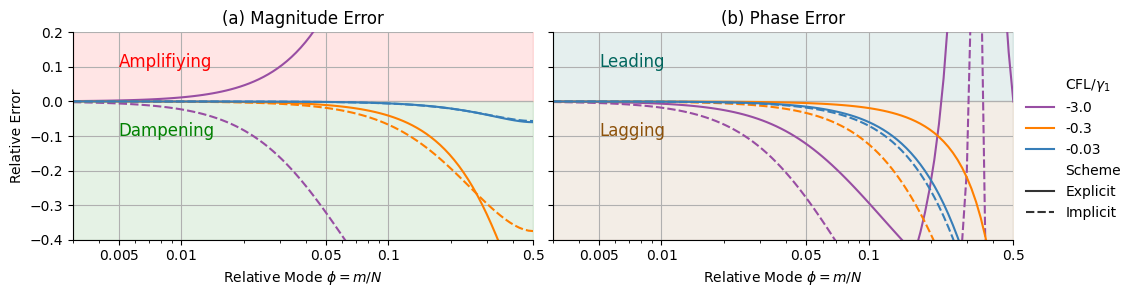

In [11]:
facet = sns.relplot(
    data=error_dfs.query("PDE == 'Advection'").rename(columns={"Parameter": "CFL/$\gamma_1$"}),
    x="phi",
    y="Error",
    hue="CFL/$\gamma_1$",
    style="Scheme",
    col="Error Type",
    kind="line",
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    aspect=1.7,
    height=3,
    # facet_kws={"sharey": False},
)


for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\phi$")
    ax.set_xlim(0.003, 0.5)
    ax.grid()
    # Set xticks to 0.005, 0.01, 0.05, 0.1, 0.5
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])

facet.axes.flat[0].set_ylim(-0.4, 0.2)
# facet.axes.flat[1].set_ylim(-0.2, 0.4)

facet.axes.flat[0].set_title("(a) Magnitude Error")
facet.axes.flat[1].set_title("(b) Phase Error")

facet.axes.flat[0].fill_between(PHI_RANGE, -0.4, 0.0, color="green", alpha=0.1)
facet.axes.flat[0].text(0.005, -0.1, "Dampening", fontsize=12, color="green")

facet.axes.flat[0].fill_between(PHI_RANGE, 0.0, 0.4, color="red", alpha=0.1)
facet.axes.flat[0].text(0.005, 0.1, "Amplifiying", fontsize=12, color="red")

facet.axes.flat[1].fill_between(PHI_RANGE, -0.4, 0.0, color="#8c510a", alpha=0.1)
facet.axes.flat[1].text(0.005, -0.1, "Lagging", fontsize=12, color="#8c510a")

facet.axes.flat[1].fill_between(PHI_RANGE, 0.0, 0.4, color="#01665e", alpha=0.1)
facet.axes.flat[1].text(0.005, 0.1, "Leading", fontsize=12, color="#01665e")

facet.axes.flat[0].set_ylabel("Relative Error")

facet.axes.flat[0].set_xlabel(r"Relative Mode $\phi=m/N$")
facet.axes.flat[1].set_xlabel(r"Relative Mode $\phi=m/N$")

facet.figure.savefig("advection_scheme_error_analysis.pdf")

Cell below reproduces Figure 8 (of the appendix) containing the relative error
in magnitude for the diffusion and Poisson equation against the analytical
solution for the explicit and implicit as well as the FD2 and Iterative schemes,
respectively.

/tmp/ipykernel_879823/3022382548.py:1: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  facet = sns.relplot(
/tmp/ipykernel_879823/3022382548.py:1: UserWarning: 
The dashes list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  facet = sns.relplot(


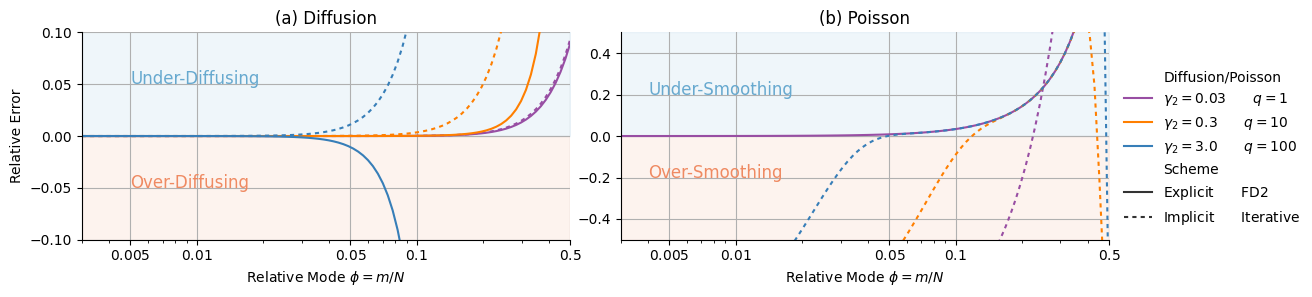

In [12]:
facet = sns.relplot(
    data=(
        error_dfs
        .query("PDE in ['Diffusion', 'Poisson']")
        .query("`Error Type` == 'Magnitude'")
        .query("`Reference` in ['Analytic']")
        .query("(PDE == 'Diffusion' and Parameter in [0.03, 0.3, 3.0]) or (PDE == 'Poisson' and Parameter in [1.0, 10.0, 100.0])")
        # .rename(columns={"Fitting Mode": "Relative Fitting\nMode $\psi=M/N$"})
    ),
    x="phi",
    y="Error",
    col="PDE",
    hue="Parameter",
    hue_order=[0.03, 0.3, 3.0, 1.0, 10.0, 100.0],
    style="Scheme",
    # style_order=[0.01, 0.1],
    # style_order=["FD2", "Iterative"],
    markers=False,
    dashes=[(None, None), (2, 2)],  # solid line for FD2, dashed for Iterative
    kind="line",
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    aspect=1.7,
    height=3,
    facet_kws={"sharey": False},
)

for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\phi$")
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.set_xlim(0.003, 0.5)
    ax.grid()
    ax.set_xlabel(r"Relative Mode $\phi=m/N$")

facet.axes.flat[0].set_ylabel(r"Relative Error")

facet.axes.flat[0].set_ylim(-0.1, 0.1)
facet.axes.flat[0].fill_between(PHI_RANGE, -0.4, 0.0, color="#ef8a62", alpha=0.1)
facet.axes.flat[0].text(0.005, -0.05, "Over-Diffusing", fontsize=12, color="#ef8a62")
facet.axes.flat[0].fill_between(PHI_RANGE, 0.0, 0.2, color="#67a9cf", alpha=0.1)
facet.axes.flat[0].text(0.005, 0.05, "Under-Diffusing", fontsize=12, color="#67a9cf")

facet.axes.flat[1].set_ylim(-0.5, 0.5)
facet.axes.flat[1].fill_between(PHI_RANGE, -0.5, 0.0, color="#ef8a62", alpha=0.1)
facet.axes.flat[1].text(0.004, -0.2, "Over-Smoothing", fontsize=12, color="#ef8a62")
facet.axes.flat[1].fill_between(PHI_RANGE, 0.0, 0.5, color="#67a9cf", alpha=0.1)
facet.axes.flat[1].text(0.004, 0.2, "Under-Smoothing", fontsize=12, color="#67a9cf")

handles = facet.legend.legend_handles
facet.legend.remove()
handles[0].set_label("Diffusion/Poisson")#\n$\\gamma_2 \\qquad \\text{Iter}$")
handles[1].set_label(r"$\gamma_2=0.03 \qquad q=1$")
handles[2].set_label(r"$\gamma_2=0.3 \qquad q=10$")
handles[3].set_label(r"$\gamma_2=3.0 \qquad q=100$")
handles[8].set_label(r"$\text{Explicit} \qquad \text{FD2}$")
handles[9].set_label(r"$\text{Implicit} \qquad \text{Iterative}$")
facet.add_legend(handles=handles[:4] + handles[7:10])

facet.axes.flat[0].set_title("(a) Diffusion")
facet.axes.flat[1].set_title("(b) Poisson")

facet.figure.savefig("diffusion_and_poisson_error_analysis.pdf", bbox_inches="tight")

# Superiority

In [13]:
adv_abs_i_i_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_abs_i_i_a,
    modules="numpy",
)
adv_abs_a_i_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_abs_a_i_a,
    modules="numpy",
)
adv_abs_i_e_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_abs_i_e_a,
    modules="numpy",
)
adv_abs_a_e_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_abs_a_e_a,
    modules="numpy",
)
adv_abs_e_i_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_abs_e_i_a,
    modules="numpy",
)
adv_abs_e_a_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_abs_e_a_a,
    modules="numpy",
)

adv_arg_i_i_a_fn = sp.lambdify(
    (phi, psi, gamma_1),
    adv_arg_i_i_a,
    modules="numpy",
)
# adv_arg_a_i_a_fn = sp.lambdify(
#     (phi, psi, gamma_1),
#     adv_arg_a_i_a,
#     modules="numpy",
# )
# adv_arg_i_e_a_fn = sp.lambdify(
#     (phi, psi, gamma_1),
#     adv_arg_i_e_a,
#     modules="numpy",
# )
# adv_arg_a_e_a_fn = sp.lambdify(
#     (phi, psi, gamma_1),
#     adv_arg_a_e_a,
#     modules="numpy",
# )
# adv_arg_e_i_a_fn = sp.lambdify(
#     (phi, psi, gamma_1),
#     adv_arg_e_i_a,
#     modules="numpy",
# )
# adv_arg_e_a_a_fn = sp.lambdify(
#     (phi, psi, gamma_1),
#     adv_arg_e_a_a,
#     modules="numpy",
# )

diff_abs_i_i_a_fn = sp.lambdify(
    (phi, psi, gamma_2),
    diff_abs_i_i_a,
    modules="numpy",
)
diff_abs_a_i_a_fn = sp.lambdify(
    (phi, psi, gamma_2),
    diff_abs_a_i_a,
    modules="numpy",
)
diff_abs_i_e_a_fn = sp.lambdify(
    (phi, psi, gamma_2),
    diff_abs_i_e_a,
    modules="numpy",
)
diff_abs_a_e_a_fn = sp.lambdify(
    (phi, psi, gamma_2),
    diff_abs_a_e_a,
    modules="numpy",
)
diff_abs_e_i_a_fn = sp.lambdify(
    (phi, psi, gamma_2),
    diff_abs_e_i_a,
    modules="numpy",
)

poiss_abs_iter_fd2_a_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_iter_fd2_a,
    modules="numpy",
)
poiss_abs_iter_iter_a_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_iter_iter_a,
    modules="numpy",
)
poiss_abs_fd2_iter_a_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_fd2_iter_a,
    modules="numpy",
)
poiss_abs_fd2_fd2_a_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_fd2_fd2_a,
    modules="numpy",
)
poiss_abs_iter_iter_fd2_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_iter_iter_fd2,
    modules="numpy",
)
poiss_abs_a_iter_a_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_a_iter_a,
    modules="numpy",
)
poiss_abs_a_fd2_a_fn = sp.lambdify(
    (phi, psi, q),
    poiss_abs_a_fd2_a,
    modules="numpy",
)

In [14]:
df_s = []

for fn, pde, error_type, train, baseline, reference, parameter in [
    (adv_abs_i_i_a_fn, "Advection", "Magnitude", "Implicit", "Implicit", "Analytic", "gamma_1"),
    (adv_abs_a_i_a_fn, "Advection", "Magnitude", "Analytic", "Implicit", "Analytic", "gamma_1"),
    (adv_abs_i_e_a_fn, "Advection", "Magnitude", "Implicit", "Explicit", "Analytic", "gamma_1"),
    (adv_abs_a_e_a_fn, "Advection", "Magnitude", "Analytic", "Explicit", "Analytic", "gamma_1"),
    (adv_abs_e_i_a_fn, "Advection", "Magnitude", "Explicit", "Implicit", "Analytic", "gamma_1"),
    (adv_abs_e_a_a_fn, "Advection", "Magnitude", "Explicit", "Analytic", "Analytic", "gamma_1"),
    (adv_arg_i_i_a_fn, "Advection", "Phase", "Implicit", "Implicit", "Analytic", "gamma_1"),
    (diff_abs_i_i_a_fn, "Diffusion", "Magnitude", "Implicit", "Implicit", "Analytic", "gamma_2"),
    (diff_abs_a_i_a_fn, "Diffusion", "Magnitude", "Analytic", "Implicit", "Analytic", "gamma_2"),
    (diff_abs_i_e_a_fn, "Diffusion", "Magnitude", "Implicit", "Explicit", "Analytic", "gamma_2"),
    (diff_abs_a_e_a_fn, "Diffusion", "Magnitude", "Analytic", "Explicit", "Analytic", "gamma_2"),
    (diff_abs_e_i_a_fn, "Diffusion", "Magnitude", "Explicit", "Implicit", "Analytic", "gamma_2"),
    (poiss_abs_iter_fd2_a_fn, "Poisson", "Magnitude", "Iterative", "FD2", "Analytic", "iteration"),
    (poiss_abs_iter_iter_a_fn, "Poisson", "Magnitude", "Iterative", "Iterative", "Analytic", "iteration"),
    (poiss_abs_fd2_iter_a_fn, "Poisson", "Magnitude", "FD2", "Iterative", "Analytic", "iteration"),
    (poiss_abs_fd2_fd2_a_fn, "Poisson", "Magnitude", "FD2", "FD2", "Analytic", None),
    (poiss_abs_iter_iter_fd2_fn, "Poisson", "Magnitude", "Iterative", "Iterative", "FD2", "iteration"),
    (poiss_abs_a_iter_a_fn, "Poisson", "Magnitude", "Analytic", "Iterative", "Analytic", "iteration"),
    (poiss_abs_a_fd2_a_fn, "Poisson", "Magnitude", "Analytic", "FD2", "Analytic", None),
    ]:
    for fitting_mode in PSI_RANGE:
        p_range = PARAMETER_RANGES[parameter]
        superiority_array = fn(PHI_RANGE.reshape(-1, 1), fitting_mode, p_range.reshape(1, -1))
        superiority_df = (
            pd.DataFrame(superiority_array, index=PHI_RANGE, columns=p_range)
            .melt(
                ignore_index=False,
                var_name="Parameter",
                value_name="Superiority",
            )
        ).reset_index(names="phi")
        superiority_df["Abs Superiority"] = np.abs(superiority_df["Superiority"])
        superiority_df["Parameter Type"] = parameter
        superiority_df["Training Scheme"] = train
        superiority_df["Baseline Scheme"] = baseline
        superiority_df["Reference Scheme"] = reference
        superiority_df["PDE"] = pde
        superiority_df["Fitting Mode"] = fitting_mode
        superiority_df["Error Type"] = error_type
        df_s.append(superiority_df)

superiority_dfs = pd.concat(df_s).reset_index(drop=True)

<lambdifygenerated-25>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.0*(sin(pi*phi)**2*abs((cos(6.28318530717959*psi)**q - 1.0)/sin(pi*phi)**2) - 1)/(2*sin(pi*phi)**2*abs((cos(2*pi*phi)**q - 1)/(cos(2*pi*phi) - 1)) - 1)
<lambdifygenerated-25>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.0*(sin(pi*phi)**2*abs((cos(6.28318530717959*psi)**q - 1.0)/sin(pi*phi)**2) - 1)/(2*sin(pi*phi)**2*abs((cos(2*pi*phi)**q - 1)/(cos(2*pi*phi) - 1)) - 1)
<lambdifygenerated-25>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.0*(sin(pi*phi)**2*abs((cos(6.28318530717959*psi)**q - 1.0)/sin(pi*phi)**2) - 1)/(2*sin(pi*phi)**2*abs((cos(2*pi*phi)**q - 1)/(cos(2*pi*phi) - 1)) - 1)
<lambdifygenerated-25>:2: RuntimeWarning: divide by zero encountered in divide
  return 1.0*(sin(pi*phi)**2*abs((cos(6.28318530717959*psi)**q - 1.0)/sin(pi*phi)**2) - 1)/(2*sin(pi*phi)**2*abs((cos(2*pi*phi)**q - 1)/(cos(2*pi*phi) - 1)) - 1)
<lambdifygenerated-25>:2: RuntimeWar

In [15]:
superiority_dfs["Reference-Baseline"] = superiority_dfs["Reference Scheme"] + "-" + superiority_dfs["Baseline Scheme"]

Cell below reproduces Figure 2 displaying superiority in magnitude and phase for
the explicit ansatz, trained on the implicit scheme, with implicit scheme as
baseline and the analytic solution as reference.

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_879823/2078635957.py:9: SyntaxWarning: invalid escape sequence '\p'
  .rename(columns={"Fitting Mode": "Relative\nFitting\nMode\n$\psi=M/N$"})
/tmp/ipykernel_879823/2078635957.py:14: SyntaxWarning: invalid escape sequence '\p'
  style="Relative\nFitting\nMode\n$\psi=M/N$",


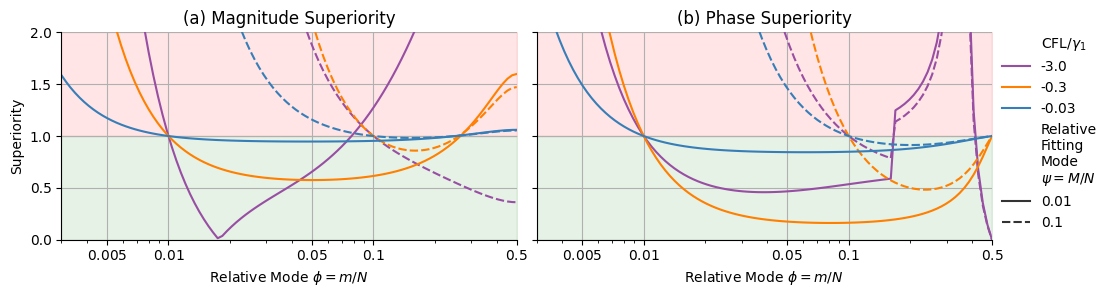

In [16]:
facet = sns.relplot(
    data=(
        superiority_dfs
        .query("PDE == 'Advection'")
        # .query("`Error Type` == 'Magnitude'")
        .query("`Training Scheme` == 'Implicit'")
        .query("`Baseline Scheme` == 'Implicit'")
        .rename(columns={"Parameter": r"CFL/$\gamma_1$"})
        .rename(columns={"Fitting Mode": "Relative\nFitting\nMode\n$\psi=M/N$"})
    ),
    x="phi",
    y="Abs Superiority",
    hue=r"CFL/$\gamma_1$",
    style="Relative\nFitting\nMode\n$\psi=M/N$",
    style_order=[0.01, 0.1],
    col="Error Type",
    kind="line",
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    aspect=1.7,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.0, 2.0)
    ax.set_xscale("log")
    ax.fill_between(PHI_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(PHI_RANGE, 1.0, 2.0, color="red", alpha=0.1)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"Superiority")
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.set_xlim(0.003, 0.5)
    ax.grid()
    ax.set_xlabel(r"Relative Mode $\phi=m/N$")

sns.move_legend(facet, "right", bbox_to_anchor=(1, 0.55))

facet.axes.flat[0].set_title("(a) Magnitude Superiority")
facet.axes.flat[1].set_title("(b) Phase Superiority")

facet.figure.savefig("advection_superiority_analysis.pdf")

Cell below reproduces Figure 3 displaying superiority in magnitude for both
Diffusion and Poisson when using an "Explicit" ansatz, trained on the
Implicit/Iterative scheme, with Implicit/Iterative as baseline and Analytic as
reference.

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_879823/2841540599.py:10: SyntaxWarning: invalid escape sequence '\p'
  .rename(columns={"Fitting Mode": "Relative Fitting\nMode $\psi=M/N$"})
/tmp/ipykernel_879823/2841540599.py:17: SyntaxWarning: invalid escape sequence '\p'
  style="Relative Fitting\nMode $\psi=M/N$",
/tmp/ipykernel_879823/2841540599.py:1: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  facet = sns.relplot(


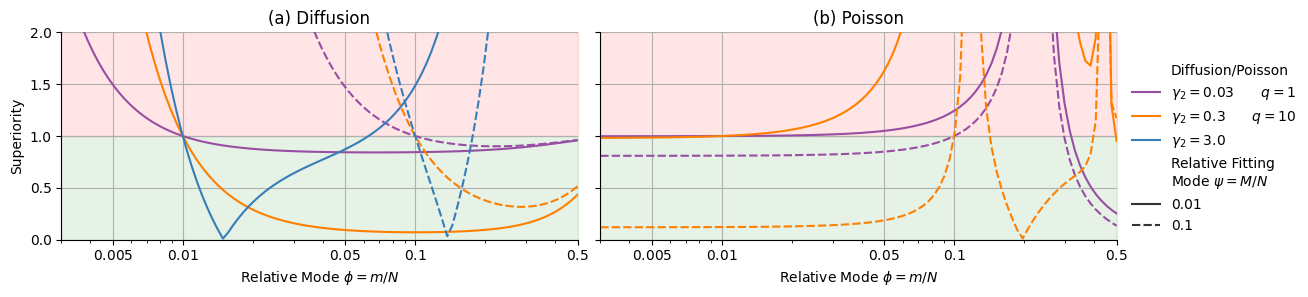

In [17]:
facet = sns.relplot(
    data=(
        superiority_dfs
        .query("PDE in ['Diffusion', 'Poisson']")
        .query("`Error Type` == 'Magnitude'")
        .query("`Training Scheme` in ['Implicit', 'Iterative']")
        .query("`Baseline Scheme` in ['Implicit', 'Iterative']")
        .query("`Reference Scheme` in ['Analytic']")
        .query("(PDE == 'Diffusion' and Parameter in [0.03, 0.3, 3.0]) or (PDE == 'Poisson' and Parameter in [1.0, 10.0])")
        .rename(columns={"Fitting Mode": "Relative Fitting\nMode $\psi=M/N$"})
    ),
    x="phi",
    y="Abs Superiority",
    col="PDE",
    hue="Parameter",
    hue_order=[0.03, 0.3, 3.0, 1.0, 10.0],
    style="Relative Fitting\nMode $\psi=M/N$",
    style_order=[0.01, 0.1],
    kind="line",
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    aspect=1.7,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.0, 2.0)
    ax.set_xscale("log")
    ax.fill_between(PHI_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(PHI_RANGE, 1.0, 2.0, color="red", alpha=0.1)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"Superiority")
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.set_xlim(0.003, 0.5)
    ax.grid()
    ax.set_xlabel(r"Relative Mode $\phi=m/N$")

handles = facet.legend.legend_handles
facet.legend.remove()
handles[0].set_label("Diffusion/Poisson")#\n$\\gamma_2 \\qquad \\text{Iter}$")
handles[1].set_label(r"$\gamma_2=0.03 \qquad q=1$")
handles[2].set_label(r"$\gamma_2=0.3 \qquad q=10$")
handles[3].set_label(r"$\gamma_2=3.0$")
facet.add_legend(handles=handles[:4] + handles[6:])

facet.axes.flat[0].set_title("(a) Diffusion")
facet.axes.flat[1].set_title("(b) Poisson")

facet.figure.savefig("diffusion_and_poisson_superiority_analysis.pdf", bbox_inches="tight")

Cell below reproduces figure 6 (of the appendix) displaying superiority in
magnitude for the advection equation using multiple combinations of training and
baseline schemes, all using the explicit ansatz and the analytic solution as
reference.

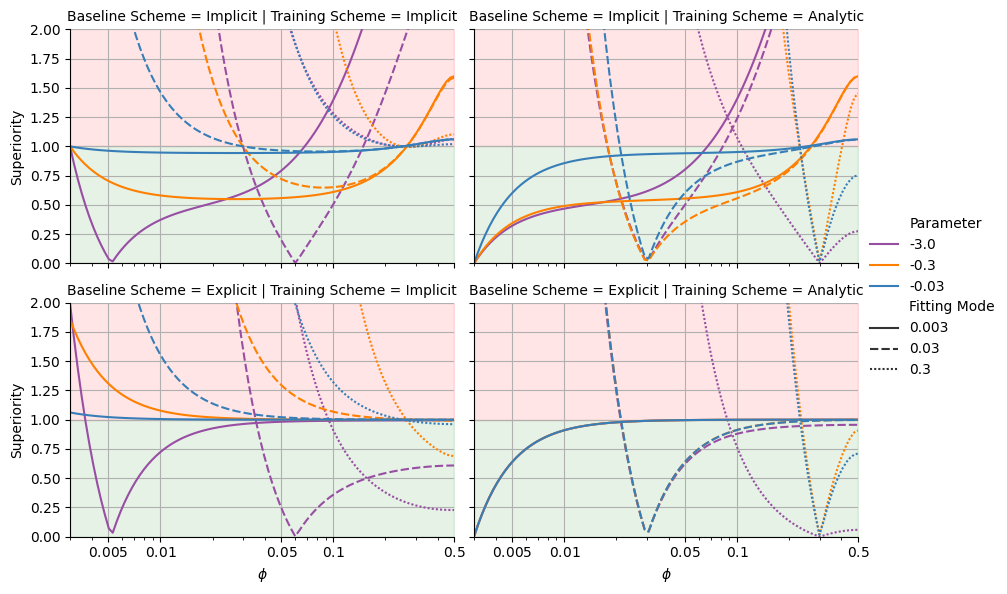

In [18]:
facet = sns.relplot(
    data=(
        superiority_dfs
        .query("PDE == 'Advection'")
        .query("`Reference Scheme` == 'Analytic'")
        .query("`Error Type` == 'Magnitude'")
    ),
    x="phi",
    y="Abs Superiority",
    hue="Parameter",
    hue_order=[-3.0, -0.3, -0.03],
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    col="Training Scheme",
    col_order=["Implicit", "Analytic"],
    row="Baseline Scheme",
    row_order=["Implicit", "Explicit"],
    style="Fitting Mode",
    style_order=[0.003, 0.03, 0.3],
    kind="line",
    aspect=1.5,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\phi$")
    ax.set_ylim(0.0, 2.0)
    ax.set_ylabel(r"Superiority")
    ax.fill_between(PHI_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(PHI_RANGE, 1.0, 2.0, color="red", alpha=0.1)
    ax.set_xlim(0.003, 0.5)
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.grid()

facet.figure.savefig("advection_superiority_analysis_more_combinations.pdf")

Cell below reproduces figure 9 (of the appendix) displaying superiority in
magnitude for the diffusion equation using multiple combinations of training and
baseline schemes, all using the explicit ansatz and the analytic solution as
reference.

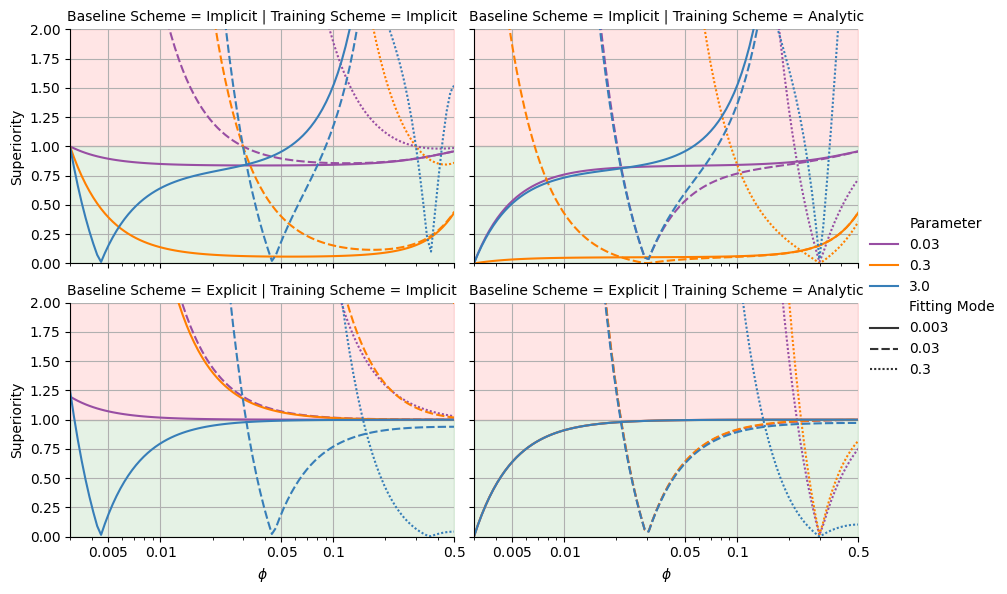

In [19]:
facet = sns.relplot(
    data=(
        superiority_dfs
        .query("PDE == 'Diffusion'")
        .query("`Reference Scheme` == 'Analytic'")
        .query("`Error Type` == 'Magnitude'")
    ),
    x="phi",
    y="Abs Superiority",
    hue="Parameter",
    # hue_order=[3.0, 0.3, 0.03],
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    col="Training Scheme",
    col_order=["Implicit", "Analytic"],
    row="Baseline Scheme",
    row_order=["Implicit", "Explicit"],
    style="Fitting Mode",
    style_order=[0.003, 0.03, 0.3],
    kind="line",
    aspect=1.5,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\phi$")
    ax.set_ylim(0.0, 2.0)
    ax.set_ylabel(r"Superiority")
    ax.fill_between(PHI_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(PHI_RANGE, 1.0, 2.0, color="red", alpha=0.1)
    ax.set_xlim(0.003, 0.5)
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.grid()

facet.figure.savefig("diffusion_superiority_analysis_more_combinations.pdf")

Cell below reproduces figure 10 (of the appendix) displaying superiority in
magnitude for the Poisson equation using multiple combinations of baseline and
reference schemes, all trained on the Iterative scheme.

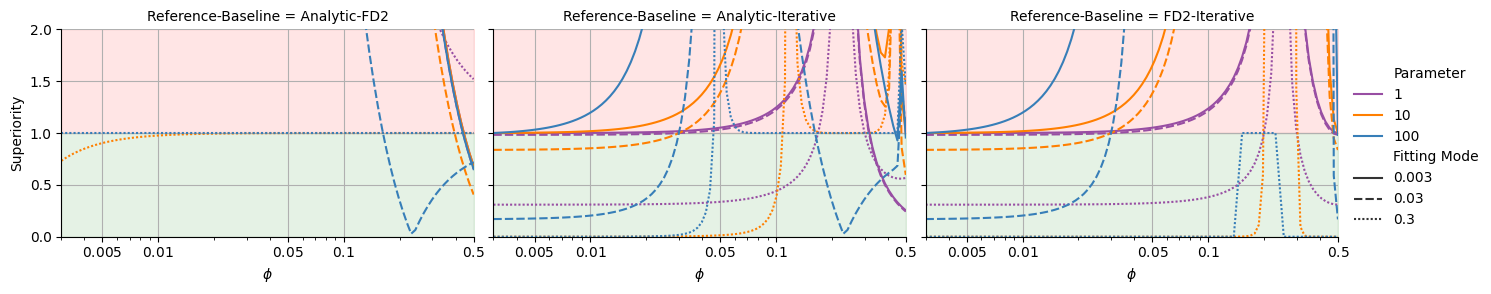

In [20]:
facet = sns.relplot(
    data=(
        superiority_dfs
        .query("PDE == 'Poisson'")
        .query("`Training Scheme` == 'Iterative'")
    ),
    x="phi",
    y="Abs Superiority",
    hue="Parameter",
    hue_order=[1, 10, 100],
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    col="Reference-Baseline",
    style="Fitting Mode",
    style_order=[0.003, 0.03, 0.3],
    kind="line",
    aspect=1.5,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\phi$")
    ax.set_ylim(0.0, 2.0)
    ax.set_ylabel(r"Superiority")
    ax.fill_between(PHI_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(PHI_RANGE, 1.0, 2.0, color="red", alpha=0.1)
    ax.set_xlim(0.003, 0.5)
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.grid()

facet.figure.savefig("poisson_superiority_analysis_more_combinations_using_iterative.pdf")

Cell below reproduces figure 11 (of the appendix) displaying superiority in
magnitude for the Poisson equation using multiple combinations of training and
reference schemes, all trained on the Analytic scheme.

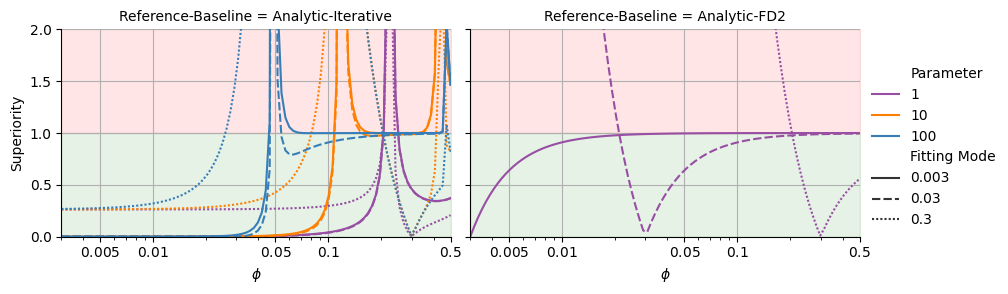

In [21]:
facet = sns.relplot(
    data=(
        superiority_dfs
        .query("PDE == 'Poisson'")
        .query("`Training Scheme` == 'Analytic'")
    ),
    x="phi",
    y="Abs Superiority",
    hue="Parameter",
    hue_order=[1, 10, 100],
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    col="Reference-Baseline",
    style="Fitting Mode",
    style_order=[0.003, 0.03, 0.3],
    kind="line",
    aspect=1.5,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel(r"$\phi$")
    ax.set_ylim(0.0, 2.0)
    ax.set_ylabel(r"Superiority")
    ax.fill_between(PHI_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(PHI_RANGE, 1.0, 2.0, color="red", alpha=0.1)
    ax.set_xlim(0.003, 0.5)
    ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5])
    ax.set_xticklabels([r"$0.005$", r"$0.01$", r"$0.05$", r"$0.1$", r"$0.5$"])
    ax.grid()

facet.figure.savefig("poisson_superiority_analysis_more_combinations_using_analytic.pdf")

# Superiority over the number of Rollout Steps

In [22]:
i_fn = sp.lambdify(
    (phi, gamma_1, psi),
    adv_i,
)
a_fn = sp.lambdify(
    (phi, gamma_1, psi),
    adv_a,
)
h_i_fn = sp.lambdify(
    (phi, gamma_1, psi),
    adv_h_i,
)

def sup_abs(phi, gamma, psi, T):
    i_val = i_fn(phi, gamma, psi)
    a_val = a_fn(phi, gamma, psi)
    h_i_val = h_i_fn(phi, gamma, psi)
    return np.abs(
        (np.abs(h_i_val**T) - np.abs(a_val**T))
        / (np.abs(i_val**T) - np.abs(a_val**T))
    )


def sup_angle(phi, gamma, psi, T):
    i_val = i_fn(phi, gamma, psi)
    a_val = a_fn(phi, gamma, psi)
    h_i_val = h_i_fn(phi, gamma, psi)
    return np.abs(
        (np.angle(h_i_val**T) - np.angle(a_val**T))
        / (np.angle(i_val**T) - np.angle(a_val**T))
    )

In [23]:
df_list = []

for fn, train_scheme, baseline_scheme, error_type, parameter in [
    (sup_abs, "Implicit", "Implicit", "Magnitude", "gamma_1"),
    (sup_angle, "Implicit", "Implicit", "Phase", "gamma_1"),
]:
    for psi in PSI_RANGE:
        for T in T_RANGE:
            p_range = PARAMETER_RANGES[parameter]
            superiority_array = np.abs(
                fn(PHI_RANGE.reshape(-1, 1), p_range.reshape(1, -1), psi, T)
            )
            superiority_df = (
                pd.DataFrame(superiority_array, index=PHI_RANGE, columns=p_range)
                .melt(
                    ignore_index=False,
                    var_name="Gamma",
                    value_name="Superiority",
                )
                .reset_index(names="phi")
            )
            superiority_df["Train Scheme"] = train_scheme
            superiority_df["Baseline Scheme"] = baseline_scheme
            superiority_df["Error Type"] = error_type
            superiority_df["Psi"] = psi
            superiority_df["T"] = T
            df_list.append(superiority_df)
superiority_dfs_over_T = pd.concat(df_list).reset_index(drop=True)

/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np.abs(a_val**T))
/tmp/ipykernel_879823/618439351.py:19: RuntimeWarning: overflow encountered in power
  (np.abs(h_i_val**T) - np

In [24]:
superiority_dfs_over_T["Analysis"] = (
    superiority_dfs_over_T["Error Type"]
    + "-"
    + superiority_dfs_over_T["Train Scheme"]
    + "-"
    + superiority_dfs_over_T["Baseline Scheme"]
)

In [25]:
superiority_dfs_over_T

,phi,Gamma,Superiority,Train Scheme,Baseline Scheme,Error Type,Psi,T,Analysis
0,0.003000,-0.03,0.942340,Implicit,Implicit,Magnitude,0.0003,1,Magnitude-Implicit-Implicit
1,0.003159,-0.03,0.942284,Implicit,Implicit,Magnitude,0.0003,1,Magnitude-Implicit-Implicit
2,0.003327,-0.03,0.942234,Implicit,Implicit,Magnitude,0.0003,1,Magnitude-Implicit-Implicit
3,0.003503,-0.03,0.942189,Implicit,Implicit,Magnitude,0.0003,1,Magnitude-Implicit-Implicit
4,0.003689,-0.03,0.942148,Implicit,Implicit,Magnitude,0.0003,1,Magnitude-Implicit-Implicit
...,...,...,...,...,...,...,...,...,...
2935795,0.406629,-3.00,0.784018,Implicit,Implicit,Phase,0.3000,99801,Phase-Implicit-Implicit
2935796,0.428195,-3.00,0.865810,Implicit,Implicit,Phase,0.3000,99801,Phase-Implicit-Implicit
2935797,0.450904,-3.00,12.841800,Implicit,Implicit,Phase,0.3000,99801,Phase-Implicit-Implicit
2935798,0.474818,-3.00,0.233739,Implicit,Implicit,Phase,0.3000,99801,Phase-Implicit-Implicit


Cell below reproduces figure 7 (of the appendix) displaying how superiority for
the advection equation in terms of both magnitude and phase varies with the
number of rollout steps for a given $\phi$ and $\psi$.

In [26]:
superiority_dfs_over_T.query("Psi == 0.003 and phi == 0.010369343339006062")

,phi,Gamma,Superiority,Train Scheme,Baseline Scheme,Error Type,Psi,T,Analysis
419424,0.010369,-0.03,0.946737,Implicit,Implicit,Magnitude,0.003,1,Magnitude-Implicit-Implicit
419524,0.010369,-0.30,0.577887,Implicit,Implicit,Magnitude,0.003,1,Magnitude-Implicit-Implicit
419624,0.010369,-3.00,0.382935,Implicit,Implicit,Magnitude,0.003,1,Magnitude-Implicit-Implicit
419724,0.010369,-0.03,0.946739,Implicit,Implicit,Magnitude,0.003,2,Magnitude-Implicit-Implicit
419824,0.010369,-0.30,0.577988,Implicit,Implicit,Magnitude,0.003,2,Magnitude-Implicit-Implicit
...,...,...,...,...,...,...,...,...,...
2096524,0.010369,-0.30,0.173382,Implicit,Implicit,Phase,0.003,99601,Phase-Implicit-Implicit
2096624,0.010369,-3.00,1.959330,Implicit,Implicit,Phase,0.003,99601,Phase-Implicit-Implicit
2096724,0.010369,-0.03,0.849057,Implicit,Implicit,Phase,0.003,99801,Phase-Implicit-Implicit
2096824,0.010369,-0.30,0.207347,Implicit,Implicit,Phase,0.003,99801,Phase-Implicit-Implicit


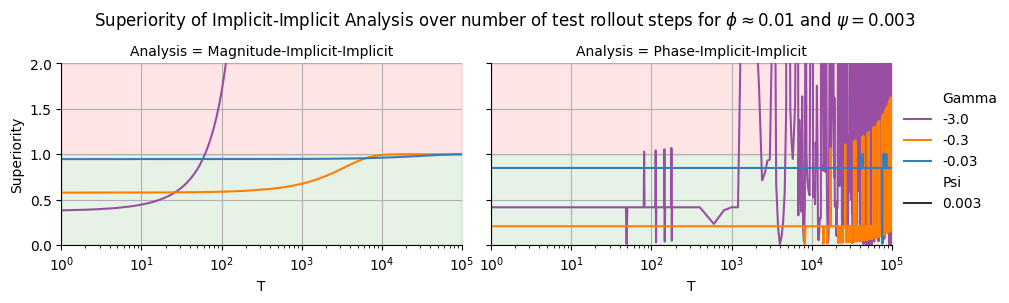

In [27]:
facet = sns.relplot(
    data=superiority_dfs_over_T.query("Psi == 0.003 and phi == 0.010369343339006062"),
    x="T",
    y="Superiority",
    hue="Gamma",
    style="Psi",
    col="Analysis",
    col_order=[
        "Magnitude-Implicit-Implicit",
        "Phase-Implicit-Implicit",
    ],
    kind="line",
    palette=["#984ea3", "#ff7f00", "#377eb8"],
    aspect=1.5,
    height=3,
)

for ax in facet.axes.flat:
    ax.set_xscale("log")
    ax.set_ylim(0.0, 2.0)
    ax.set_xlim(1, 100_000)
    ax.grid()
    ax.fill_between(T_RANGE, 0.0, 1.0, color="green", alpha=0.1)
    ax.fill_between(T_RANGE, 1.0, 2.0, color="red", alpha=0.1)

facet.figure.subplots_adjust(top=0.8)
facet.figure.suptitle(
    r"Superiority of Implicit-Implicit Analysis over number of test rollout steps for $\phi \approx 0.01$ and $\psi = 0.003$"
)

facet.figure.savefig("advection_superiority_over_T.pdf")

# Write out Symbolic Expressions

Running the cell below can take up to 1min

In [28]:
html_str = """<!DOCTYPE html>
<html lang="en">
<head>
<title>Symbolic Expressions for Emulator Superiority</title>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">

<script>
MathJax = {
  tex: {
    inlineMath: [['$', '$'], ['\\(', '\\)']]
  },
  svg: {
    fontCache: 'global'
  }
};
</script>
<script type="text/javascript" id="MathJax-script" async
  src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-svg.js">
</script>
<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/css/bootstrap.min.css" integrity="sha384-Gn5384xqQ1aoWXA+058RXPxPg6fy4IWvTNh0E263XmFcJlSAwiGgFAW/dAiS6JXm" crossorigin="anonymous">
</head>
<body class="p-2">
<h1 class="text-center">Symbolic Expressions for Emulator Superiority</h1>

<table class="table table-striped table-hover">
  <thead>
    <tr>
      <th>Name</th>
      <th>Expression</th>
    </tr>
  </thead>
  <tbody>
"""

In [29]:
# Due to the simplification, this can take a while to be produced


# Latex commands cannot end in numerals
with open("symbolic_expressions.tex", "w") as f:
    for name, expr in [
    # All for advection
    ("advE", adv_e),
    ("advI", adv_i),
    ("advA", adv_a),
    ("advH", adv_h),

    ("advMagnitudeErrorE", adv_magnitude_error_e),
    ("advMagnitudeErrorI", adv_magnitude_error_i),
    ("advPhaseErrorE", adv_phase_error_e),
    ("advPhaseErrorI", adv_phase_error_i),

    ("advISolTFirst", adv_i_sol[theta_0].simplify()),
    ("advISolTSecond", adv_i_sol[theta_1].simplify()),
    ("advASolTFirst", adv_a_sol[theta_0].simplify()),
    ("advASolTSecond", adv_a_sol[theta_1].simplify()),
    ("advESolTFirst", adv_e_sol[theta_0].simplify()),
    ("advESolTSecond", adv_e_sol[theta_1].simplify()),

    ("advHE", adv_h_e),
    ("advHA", adv_h_a),
    ("advHI", adv_h_i),

    ("advSupMagIIA", adv_abs_i_i_a),
    ("advSupMagAIA", adv_abs_a_i_a),
    ("advSupMagIEA", adv_abs_i_e_a),
    ("advSupMagAEA", adv_abs_a_e_a),
    ("advSupMagEIA", adv_abs_e_i_a),
    ("advSupMagEAA", adv_abs_e_a_a),
    
    ("advSupPhaseIIA", adv_arg_i_i_a),
    ("advSupPhaseAIA", adv_arg_a_i_a),
    ("advSupPhaseIEA", adv_arg_i_e_a),
    ("advSupPhaseAEA", adv_arg_a_e_a),
    ("advSupPhaseEIA", adv_arg_e_i_a),
    ("advSupPhaseEAA", adv_arg_e_a_a),

    # All for diffusion
    ("diffE", diff_e),
    ("diffI", diff_i),
    ("diffA", diff_a),
    ("diffH", diff_h),

    ("diffMagnitudeErrorE", diff_magnitude_error_e),
    ("diffMagnitudeErrorI", diff_magnitude_error_i),

    ("diffISol", diff_i_sol),
    ("diffASol", diff_a_sol),
    ("diffESol", diff_e_sol),

    ("diffHI", diff_h_i),
    ("diffHA", diff_h_a),
    ("diffHE", diff_h_e),

    ("diffSupMagIIA", diff_abs_i_i_a),
    ("diffSupMagAIA", diff_abs_a_i_a),
    ("diffSupMagIEA", diff_abs_i_e_a),
    ("diffSupMagAEA", diff_abs_a_e_a),
    ("diffSupMagEIA", diff_abs_e_i_a),
    
    # All for poisson
    ("poissFD", poiss_fd2),
    ("poissA", poiss_a),
    ("poissIter", poiss_iter),
    ("poissH", poiss_h),

    ("poissMagnitudeErrorFD", poiss_magnitude_error_fd2),
    ("poissMagnitudeErrorIter", poiss_magnitude_error_iterative),
    ("poissMagnitudeErrorIterAgainstFD", poiss_magnitude_error_iterative_against_fd2),
    
    ("poissIterSol", poiss_iter_sol),
    ("poissFDSol", poiss_fd2_sol),
    ("poissASol", poiss_a_sol),
    
    ("poissHIter", poiss_h_iter),
    ("poissHFD", poiss_h_fd2),
    ("poissHA", poiss_h_a),
    
    ("poissSupMagIterFDA", poiss_abs_iter_fd2_a),
    ("poissSupMagIterIterA", poiss_abs_iter_iter_a),
    ("poissSupMagFDIterA", poiss_abs_fd2_iter_a),
    ("poissSupMagFDFDA", poiss_abs_fd2_fd2_a),
    ("poissSupMagIterIterFD", poiss_abs_iter_iter_fd2),
    ("poissSupMagAIterA", poiss_abs_a_iter_a),
    ("poissSupMagAFD2A", poiss_abs_a_fd2_a),
]:
        f.write(f"\\newcommand{{\\{name}}}{{{sp.latex(expr, mul_symbol='dot', long_frac_ratio=10.0)}}}\n")
        html_str += "<tr>\n"
        html_str += f"<td>{name}</td>"
        html_str += f"<td>{sp.latex(expr, mul_symbol='dot', long_frac_ratio=10.0, mode='inline')}</td>"
        html_str += "</tr>"

In [30]:
html_str += """
  </tbody>
</table> 


<script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0-alpha1/dist/js/bootstrap.bundle.min.js" integrity="sha384-w76AqPfDkMBDXo30jS1Sgez6pr3x5MlQ1ZAGC+nuZB+EYdgRZgiwxhTBTkF7CXvN" crossorigin="anonymous"></script>
</body>
</html>
"""

In [31]:
with open("symbolic_expressions.html", "w") as f:
    f.write(html_str)
